## Run Hypertunning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import rpy2.robjects as robjects

In [2]:
from forecast_research.energy_price.custom_losses import (
    dirichlet_layer,
    EvidentialLoss,
    AnnealingCallback,
    evidential_kl_divergence,
    cross_entropy_loss,
)

from forecast_research.energy_price.helpers import (
    load_rds_array,
    plot_training_history,
)

2026-04-02 14:55:17.566252: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-02 14:57:41.576992: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775167062.482282 3903402 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775167063.038062 3903402 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775167066.180538 3903402 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

ImportError: cannot import name 'plot_training_history' from 'forecast_research.energy_price.helpers' (/project/6004619/dcs01/forecast_research/energy_price/helpers.py)

Read files in energy_data folder


In [3]:
X_train,     (_, _, feature_names)    = load_rds_array('energy_data/X_train.rds')
Y_train,     (_, _, state_names)      = load_rds_array('energy_data/Y_train.rds')
Y_hat_train, (_, _, state_names_hat)  = load_rds_array('energy_data/Y_hat_train.rds')

X_valid,     _ = load_rds_array('energy_data/X_valid.rds')
Y_valid,     _ = load_rds_array('energy_data/Y_valid.rds')
Y_hat_valid, _ = load_rds_array('energy_data/Y_hat_valid.rds')
Y_date_valid = Y_valid[:, :, 0]  # Extract date dimension for validation set
Y_valid = Y_valid[:, :, 1:].astype(float)  # Extract state probabilities and convert to numeric
Y_hat_valid = Y_hat_valid[:, :, 1:].astype(float)  # Extract state probabilities for validation set predictions

X_test,      _ = load_rds_array('energy_data/X_test.rds')
Y_test,      _ = load_rds_array('energy_data/Y_test.rds')
Y_hat_test,  _ = load_rds_array('energy_data/Y_hat_test.rds')
Y_date_test = Y_test[:, :, 0]  # Extract date dimension for test set
Y_test = Y_test[:, :, 1:].astype(float)  # Extract state probabilities and convert to numeric
Y_hat_test = Y_hat_test[:, :, 1:].astype(float)  # Extract state probabilities for test set predictions

print("X_train:    ", X_train.shape)
print("Y_train:    ", Y_train.shape)
print("Y_hat_train:", Y_hat_train.shape)
print("\nFeature names:", feature_names)
print("State names:  ", state_names)


X_train:     (3510, 10, 14)
Y_train:     (3510, 10, 4)
Y_hat_train: (3510, 10, 4)

Feature names: ['date', 'renewable_penetration', 'renewable_penetration_30d_avg', 'gas_share', 'gas_share_30d_avg', 'coal_share', 'coal_share_30d_avg', 'net_export_ratio', 'relative_demand', 'gas_price', 'month', 'state_prob_1', 'state_prob_2', 'state_prob_3']
State names:   ['date', 'gt_1', 'gt_2', 'gt_3']


### Convert to single forecast training splits

In [ ]:
forecast_horizon = Y_train.shape[1]

dt_col_names = ['month']
x_cols       = [i for i, n in enumerate(feature_names) if n != 'date' and n not in dt_col_names]
x_dt_cols    = [i for i, n in enumerate(feature_names) if n in dt_col_names]
y_cols       = [i for i, n in enumerate(state_names)   if n != 'date']
x_date_idx   = feature_names.index('date')
y_date_idx   = state_names.index('date')

def prepare_data_with_horizon(X, Y, shuffle=True):
    x_dates = X[:, :, x_date_idx]
    y_dates = Y[:, :, y_date_idx]

    X_cov = X[:, :, x_cols].astype(float)
    X_dt  = X[:, :, x_dt_cols].astype(float)
    Y     = Y[:, :, y_cols].astype(float)

    n_samples = X_cov.shape[0]

    horizon_input = np.repeat(np.eye(forecast_horizon), n_samples, axis=0)
    X_cov_out     = np.concatenate([X_cov] * forecast_horizon, axis=0)
    X_dt_out      = np.concatenate([X_dt]  * forecast_horizon, axis=0)
    Y_out         = np.concatenate([Y[:, i, :] for i in range(forecast_horizon)], axis=0)
    x_dates_out   = np.tile(x_dates, (forecast_horizon, 1))[:, :, np.newaxis]
    y_dates_out   = np.concatenate([y_dates[:, i] for i in range(forecast_horizon)])[:, np.newaxis]
    y_month_out   = pd.get_dummies(pd.to_datetime(y_dates_out.flatten()).month, prefix='month').values.astype(int)

    if shuffle:
        idx           = np.random.permutation(X_cov_out.shape[0])
        X_cov_out     = X_cov_out[idx]
        X_dt_out      = X_dt_out[idx]
        horizon_input = horizon_input[idx]
        Y_out         = Y_out[idx]
        x_dates_out   = x_dates_out[idx]
        y_dates_out   = y_dates_out[idx]
        y_month_out   = y_month_out[idx]


    return X_cov_out, X_dt_out, horizon_input, Y_out, x_dates_out, y_dates_out, y_month_out

X_train_cov, X_train_dt, horizon_train, Y_train_h, dates_train, Y_dates_train, Y_month_train = prepare_data_with_horizon(X_train, Y_train, shuffle=True)
X_valid_cov, X_valid_dt, horizon_valid, Y_valid_h, dates_valid, Y_dates_valid, Y_month_valid = prepare_data_with_horizon(X_valid, Y_valid, shuffle=False)
X_test_cov,  X_test_dt,  horizon_test,  Y_test_h,  dates_test,  Y_dates_test, Y_month_test  = prepare_data_with_horizon(X_test,  Y_test,  shuffle=False)

print("X_train_cov:  ", X_train_cov.shape)   # (samples*horizon, lookback, 12)
print("X_train_dt:   ", X_train_dt.shape)    # (samples*horizon, lookback, 2)
print("horizon_train:", horizon_train.shape)  # (samples*horizon, horizon)
print("Y_train_h:    ", Y_train_h.shape)      # (samples*horizon, states)
print("Y_month_train:", Y_month_train.shape)     # (samples*horizon, 1)
print()
print("Cov features: ", [n for n in feature_names if n != 'date' and n not in dt_col_names])
print("DT features:  ", dt_col_names)


X_train_cov:   (35100, 10, 12)
X_train_dt:    (35100, 10, 1)
horizon_train: (35100, 10)
Y_train_h:     (35100, 3)
Y_month_train: (35100, 12)

Cov features:  ['renewable_penetration', 'renewable_penetration_30d_avg', 'gas_share', 'gas_share_30d_avg', 'coal_share', 'coal_share_30d_avg', 'net_export_ratio', 'relative_demand', 'gas_price', 'state_prob_1', 'state_prob_2', 'state_prob_3']
DT features:   ['month']


In [ ]:
import os
import numpy as np

# Create the new folder if it doesn't exist
os.makedirs('energy_data/ml_data', exist_ok=True)

# Save X_train_cov
np.save('energy_data/ml_data/X_train_cov.npy', X_train_cov)
np.save('energy_data/ml_data/X_train_dt.npy', X_train_dt)
np.save('energy_data/ml_data/horizon_train.npy', horizon_train)
np.save('energy_data/ml_data/Y_train_h.npy', Y_train_h)
np.save('energy_data/ml_data/dates_train.npy', dates_train)
np.save('energy_data/ml_data/Y_dates_train.npy', Y_dates_train)
np.save('energy_data/ml_data/Y_month_train.npy', Y_month_train)

# Save X_valid_cov
np.save('energy_data/ml_data/X_valid_cov.npy', X_valid_cov)
np.save('energy_data/ml_data/X_valid_dt.npy', X_valid_dt)
np.save('energy_data/ml_data/horizon_valid.npy', horizon_valid)
np.save('energy_data/ml_data/Y_valid_h.npy', Y_valid_h)
np.save('energy_data/ml_data/dates_valid.npy', dates_valid)
np.save('energy_data/ml_data/Y_dates_valid.npy', Y_dates_valid)
np.save('energy_data/ml_data/Y_month_valid.npy', Y_month_valid)

# Save Y_month_test
np.save('energy_data/ml_data/X_test_cov.npy', X_test_cov)
np.save('energy_data/ml_data/X_test_dt.npy', X_test_dt)
np.save('energy_data/ml_data/horizon_test.npy', horizon_test)
np.save('energy_data/ml_data/Y_test_h.npy', Y_test_h)
np.save('energy_data/ml_data/dates_test.npy', dates_test)
np.save('energy_data/ml_data/Y_dates_test.npy', Y_dates_test)
np.save('energy_data/ml_data/Y_month_test.npy', Y_month_test)

print("Data saved to energy_data/ml_data/")

Data saved to energy_data/ml_data/


## Create custom Dirichlet layer and callbacks

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.losses import kullback_leibler_divergence
from tensorflow.keras.layers import Concatenate

### Create the model
Using RNN layer, followed by 2 dense ouput layers with callbacks

In [ ]:
def build_model(lookback, n_cov_features, n_dt_features, n_states,
                loss_type='mse',
                embedding_dim=8, rnn_units=8, n_dense_layers=2, dense_units=16,
                dropout_rate=0.5, learning_rate=0.001,
                annealing_rate=100.0, max_annealing_rate=0.2):

    # Covariate time-series input: (lookback, n_cov_features)
    cov_input     = layers.Input(shape=(lookback, n_cov_features), name='cov_input')
    # Date/time input: (lookback, n_dt_features) — flatten across time before embedding
    dt_input      = layers.Input(shape=(n_dt_features, ),  name='dt_input')
    # One-hot horizon input: (forecast_horizon,)
    horizon_input = layers.Input(shape=(forecast_horizon,),        name='horizon_input')

    # Flatten dt across time then project to embedding
    dt_flat  = layers.Flatten()(dt_input)
    dt_embed = layers.Dense(embedding_dim, activation='relu')(dt_flat)

    # Project horizon to embedding
    horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)

    # RNN over covariate time-series
    rnn_out = layers.SimpleRNN(rnn_units, dropout=dropout_rate)(cov_input)

    # Merge all representations
    x = Concatenate()([rnn_out, dt_embed, horizon_embed])

    # Variable-depth dense head
    for _ in range(n_dense_layers):
        x = layers.Dense(dense_units, activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)

    # Output raw evidence (non-negative) — softplus ensures > 0
    output = layers.Dense(n_states, activation='softplus')(x)

    model = models.Model(inputs=[cov_input, dt_input, horizon_input], outputs=output)
    model.compile(
        loss=EvidentialLoss(loss_type=loss_type, annealing_rate=annealing_rate, max_annealing_rate=max_annealing_rate),
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=[evidential_kl_divergence, cross_entropy_loss]
    )
    return model


# Derive dimensions from prepared arrays
lookback       = X_train_cov.shape[1]
n_cov_features = X_train_cov.shape[2]
n_dt_features  = Y_month_train.shape[1]
n_states       = Y_train_h.shape[1]


Epoch 1/120
  87/1097 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cross_entropy_loss: 1.0905 - evidential_kl_divergence: 0.6982 - loss: 0.5149

2026-04-02 13:08:43.192897: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_select_fusion', 24 bytes spill stores, 24 bytes spill loads



1097/1097 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cross_entropy_loss: 1.0344 - evidential_kl_divergence: 0.6333 - loss: 0.4381

2026-04-02 13:08:47.888486: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_select_fusion', 24 bytes spill stores, 24 bytes spill loads



1097/1097 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - cross_entropy_loss: 0.9993 - evidential_kl_divergence: 0.5963 - loss: 0.3993 - val_cross_entropy_loss: 0.9588 - val_evidential_kl_divergence: 0.5119 - val_loss: 0.3355
Epoch 2/120
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 0.9573 - evidential_kl_divergence: 0.5543 - loss: 0.3553 - val_cross_entropy_loss: 0.9422 - val_evidential_kl_divergence: 0.4953 - val_loss: 0.3214
Epoch 3/120
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - cross_entropy_loss: 0.9470 - evidential_kl_divergence: 0.5440 - loss: 0.3446 - val_cross_entropy_loss: 0.9359 - val_evidential_kl_divergence: 0.4891 - val_loss: 0.3169
Epoch 4/120
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 0.9424 - evidential_kl_divergence: 0.5394 - loss: 0.3397 - val_cross_entropy_loss: 0.9384 - val_evidential_kl_divergence: 0.4916 - val_loss: 0.3156
Epoch 5/120
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 0.9385 - evidential_kl_divergence:

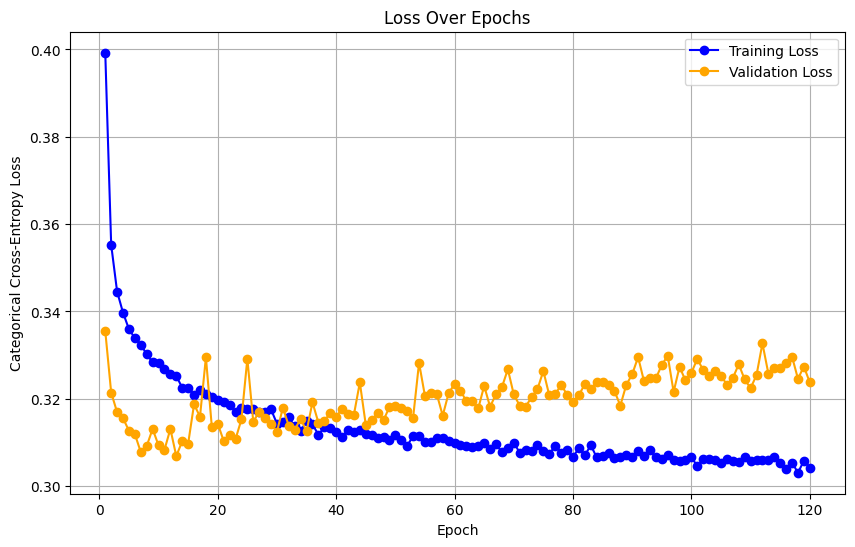

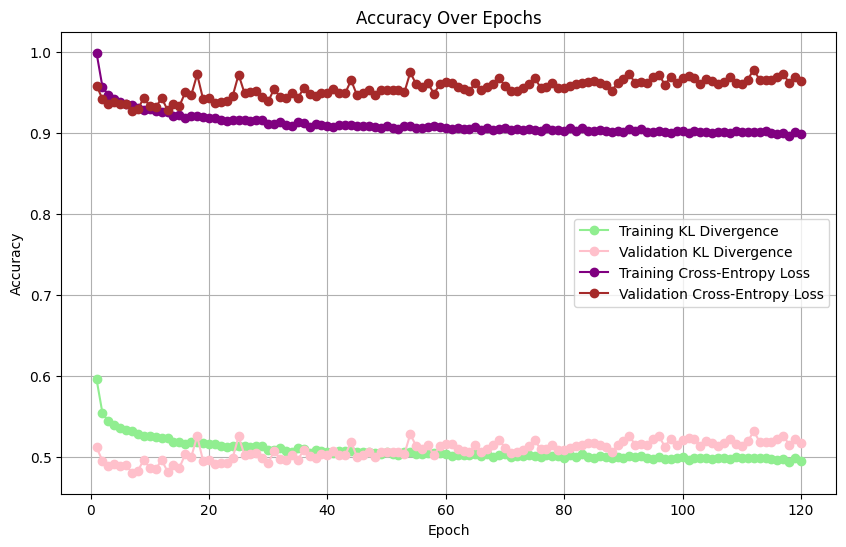

In [ ]:
tf.keras.backend.clear_session()

model = build_model(lookback, n_cov_features, n_dt_features, n_states,
                    loss_type='mse',
                    embedding_dim=8, rnn_units=8, n_dense_layers=1, dense_units=16,
                    dropout_rate=0.3, learning_rate=0.001,
                    annealing_rate=150.0, max_annealing_rate=0)

history = model.fit(
    [X_train_cov, Y_month_train, horizon_train], Y_train_h,
    validation_data=([X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h),
    callbacks=[AnnealingCallback()],
    epochs=120,  # Use the same number as in your tuner setup
    verbose=1  # Set to 0 for silent output if preferred
)
plot_training_history(history)

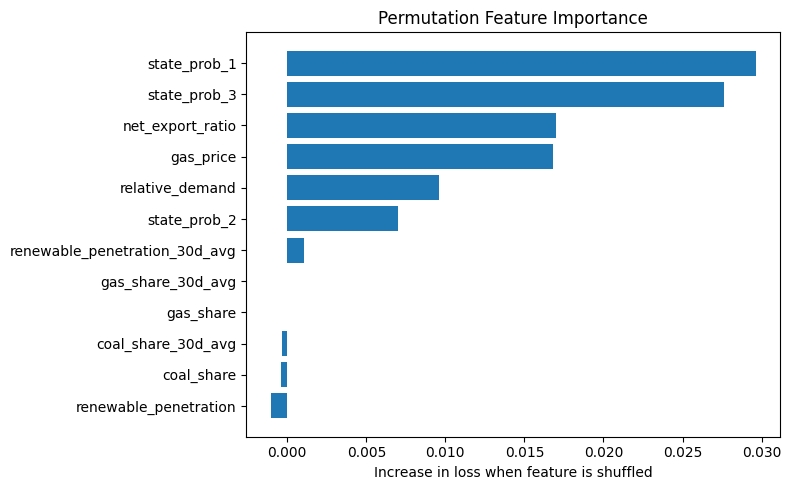

In [ ]:
best_model = model
cov_feature_names = [n for n in feature_names if n != 'date' and n not in dt_col_names]

base_loss = best_model.evaluate(
    [X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h, verbose=0
)[0]

importances = {}
for i, name in enumerate(cov_feature_names):
    X_perm = X_valid_cov.copy()
    np.random.shuffle(X_perm[:, :, i])  # shuffle that feature across samples
    perm_loss = best_model.evaluate(
        [X_perm, Y_month_valid, horizon_valid], Y_valid_h, verbose=0
    )[0]
    importances[name] = perm_loss - base_loss

# Plot
names, scores = zip(*sorted(importances.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(8, 5))
plt.barh(names[::-1], scores[::-1])
plt.xlabel("Increase in loss when feature is shuffled")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()



/tmp/ipykernel_2894083/1190128375.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


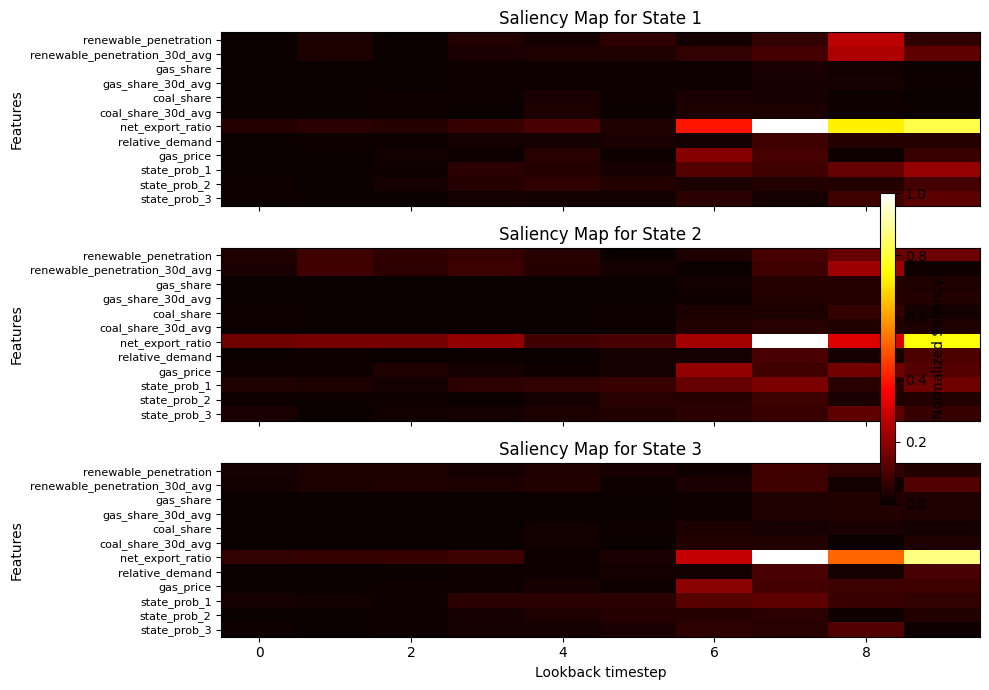

In [ ]:
best_model = model
cov_feature_names = [n for n in feature_names if n != 'date' and n not in dt_col_names]

# Select a sample input
sample_idx = 2
sample_cov     = tf.convert_to_tensor(X_valid_cov[sample_idx:sample_idx+1],   dtype=tf.float32)
sample_month   = tf.convert_to_tensor(Y_month_valid[sample_idx:sample_idx+1], dtype=tf.float32)
sample_horizon = tf.convert_to_tensor(horizon_valid[sample_idx:sample_idx+1], dtype=tf.float32)

saliency_maps = []

for target_class in range(n_states):
    with tf.GradientTape() as tape:
        tape.watch(sample_cov)
        predictions = best_model([sample_cov, sample_month, sample_horizon], training=False)
        class_output = predictions[:, target_class]

    gradients = tape.gradient(class_output, sample_cov)
    saliency_map = tf.abs(gradients).numpy()[0]  # (lookback, n_cov_features)
    saliency_map = saliency_map.T                # (n_cov_features, lookback)
    saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min() + 1e-8)
    saliency_maps.append(saliency_map)

fig, axs = plt.subplots(n_states, 1, figsize=(10, 7), sharex=True)

for i, ax in enumerate(axs):
    im = ax.imshow(saliency_maps[i], cmap='hot', aspect='auto')
    ax.set_title(f'Saliency Map for State {i + 1}')
    ax.set_ylabel('Features')
    ax.set_yticks(range(len(cov_feature_names)))
    ax.set_yticklabels(cov_feature_names, fontsize=8)

axs[-1].set_xlabel('Lookback timestep')
fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.02, pad=0.04, label='Normalized Saliency')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2894083/4244222927.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


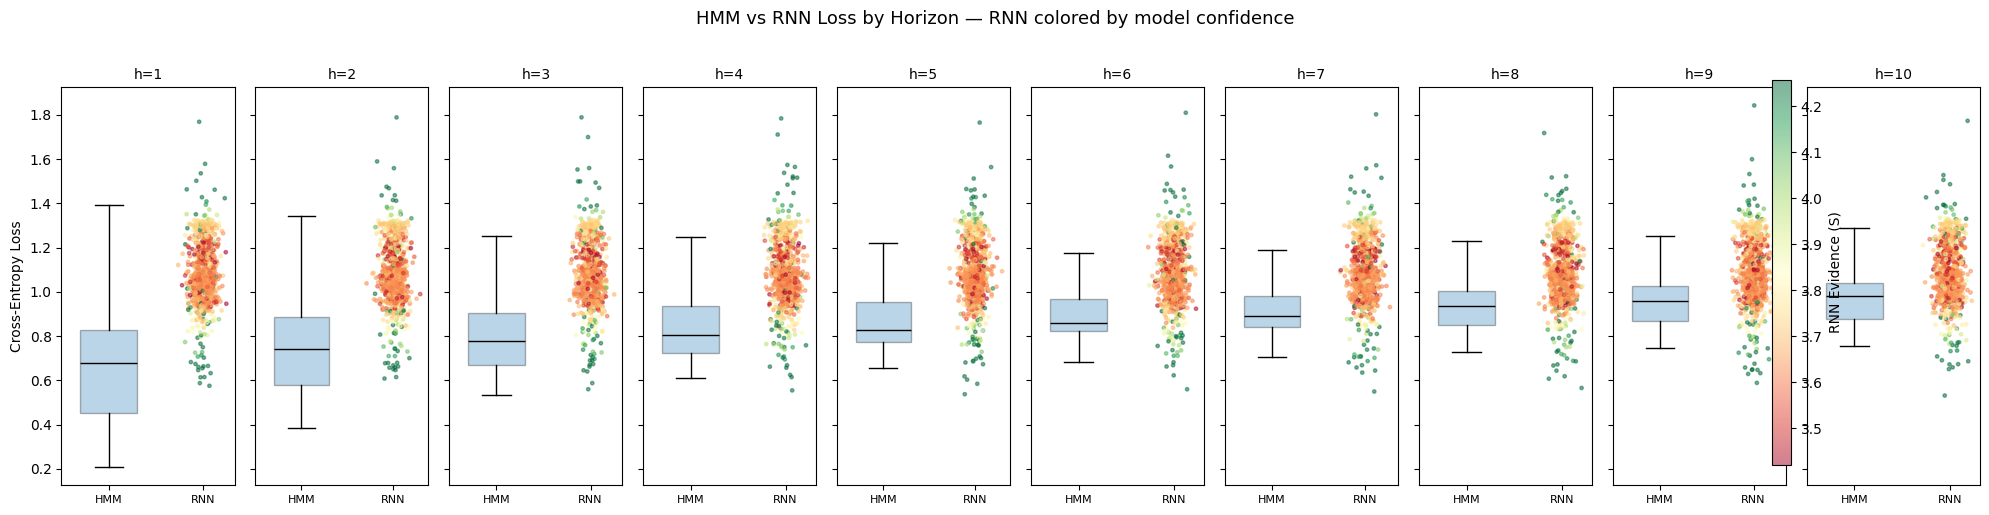

In [ ]:
# Scatter: RNN loss colored by evidence, HMM boxplot as reference
fig, axes = plt.subplots(1, forecast_horizon, figsize=(20, 5), sharey=True)

for h in range(forecast_horizon):
    ax = axes[h]

    # HMM boxplot as background reference
    ax.boxplot(hmm_loss_test[:, h], positions=[0], widths=0.6,
               patch_artist=True, showfliers=False,
               boxprops=dict(facecolor='#1f77b4', alpha=0.3),
               medianprops=dict(color='black'))

    # RNN scatter colored by evidence S
    sc = ax.scatter(
        np.random.normal(1, 0.08, n_samples_test),  # jitter x position
        rnn_loss_test[:, h],
        c=rnn_s_test[:, h],
        cmap='RdYlGn',  # red=low evidence, green=high evidence
        s=6, alpha=0.5,
        vmin=np.percentile(rnn_s_test, 5),
        vmax=np.percentile(rnn_s_test, 95),
    )

    ax.set_title(f'h={h+1}', fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['HMM', 'RNN'], fontsize=8)
    if h == 0:
        ax.set_ylabel('Cross-Entropy Loss')

fig.colorbar(sc, ax=axes, orientation='vertical', fraction=0.015, pad=0.02, label='RNN Evidence (S)')
fig.suptitle('HMM vs RNN Loss by Horizon — RNN colored by model confidence', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2894083/3007314809.py:17: RuntimeWarning: Mean of empty slice.
  rnn_mean[h] = rnn_loss_test[mask, h].mean()
/home/dcs01/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


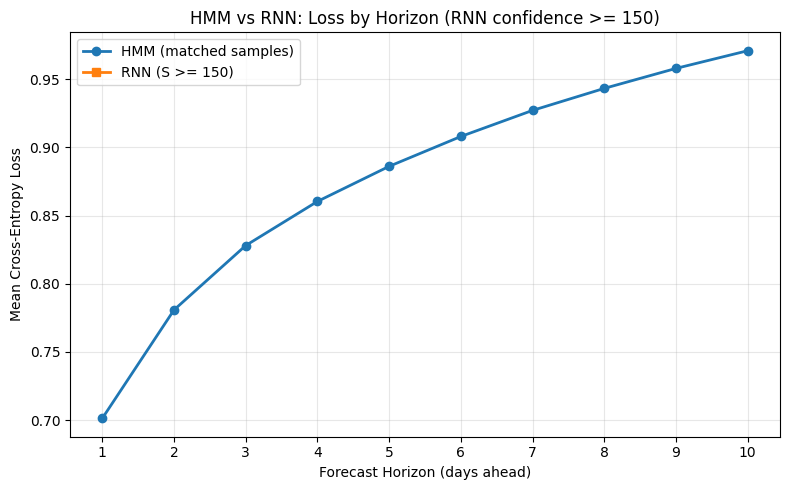

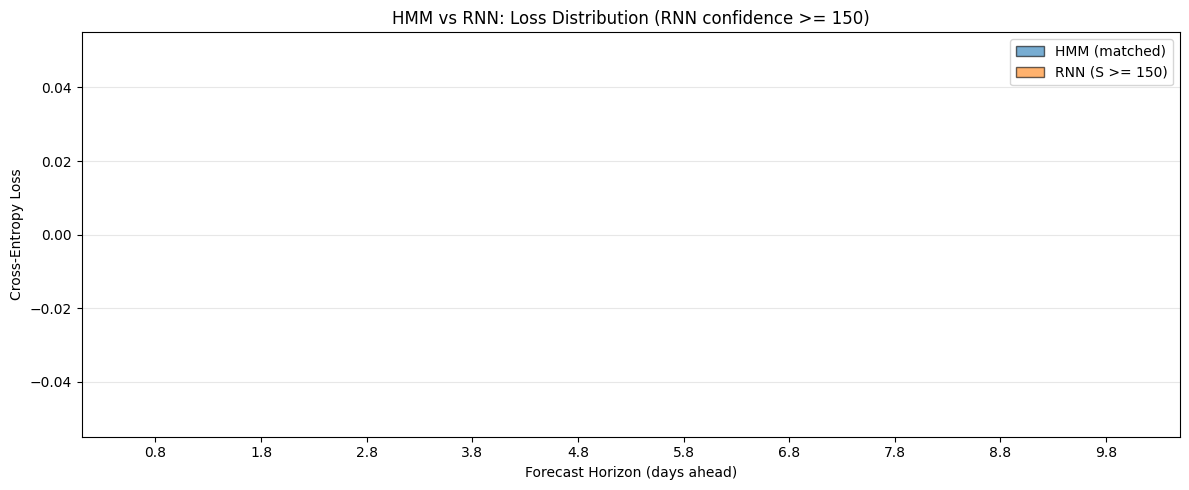

In [ ]:
confidence_threshold = 150

# --- Plot 1: Mean loss by horizon (RNN filtered by S >= threshold) ---
fig, ax = plt.subplots(figsize=(8, 5))
horizons = np.arange(1, forecast_horizon + 1)

hmm_mean = np.zeros(forecast_horizon)
rnn_mean = np.zeros(forecast_horizon)
rnn_count = np.zeros(forecast_horizon)

mask_2d = np.zeros((n_samples_test, forecast_horizon), dtype=bool)
for h in range(forecast_horizon):
    mask = rnn_s_test[:, h] >= confidence_threshold
    mask = np.array(mask[:, 0])
    mask_2d[:, h] = mask
    hmm_mean[h] = hmm_loss_test[:, h].mean()
    rnn_mean[h] = rnn_loss_test[mask, h].mean()

ax.plot(horizons, hmm_mean, 'o-', label='HMM (matched samples)', linewidth=2)
ax.plot(horizons, rnn_mean, 's-', label=f'RNN (S >= {confidence_threshold})', linewidth=2)
ax.set_xlabel('Forecast Horizon (days ahead)')
ax.set_ylabel('Mean Cross-Entropy Loss')
ax.set_title(f'HMM vs RNN: Loss by Horizon (RNN confidence >= {confidence_threshold})')
ax.set_xticks(horizons)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Boxplot side-by-side (filtered) ---
fig, ax = plt.subplots(figsize=(12, 5))
positions_hmm = horizons - 0.2
positions_rnn = horizons + 0.2

hmm_filtered = [hmm_loss_test[mask_2d[:, h], h] for h in range(forecast_horizon)]
rnn_filtered = [rnn_loss_test[mask_2d[:, h], h] for h in range(forecast_horizon)]

bp_hmm = ax.boxplot(hmm_filtered, positions=positions_hmm, widths=0.3,
                     patch_artist=True, showfliers=False,
                     boxprops=dict(facecolor='#1f77b4', alpha=0.6),
                     medianprops=dict(color='black'))
bp_rnn = ax.boxplot(rnn_filtered, positions=positions_rnn, widths=0.3,
                     patch_artist=True, showfliers=False,
                     boxprops=dict(facecolor='#ff7f0e', alpha=0.6),
                     medianprops=dict(color='black'))

ax.set_xlabel('Forecast Horizon (days ahead)')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title(f'HMM vs RNN: Loss Distribution (RNN confidence >= {confidence_threshold})')
ax.set_xticks(horizons)
ax.legend([bp_hmm['boxes'][0], bp_rnn['boxes'][0]], ['HMM (matched)', f'RNN (S >= {confidence_threshold})'])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Predict on test set
rnn_y_valid = best_model.predict([X_valid_cov, Y_month_valid, horizon_valid])
rnn_y_test = best_model.predict([X_test_cov, Y_month_test, horizon_test])

# Convert rnn_y_test from shape (n_samples * forecast_horizon, n_states) to (n_samples, forecast_horizon, n_states)
def convert_to_3d(arr, horizon):
    n_samples = arr.shape[0] // horizon
    return arr.reshape(n_samples, horizon, -1)

rnn_y_reshaped_valid = convert_to_3d(rnn_y_valid, forecast_horizon)
rnn_y_reshaped_test = convert_to_3d(rnn_y_test, forecast_horizon)

def compute_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)    
    return -np.sum(y_true * np.log(y_pred), axis=-1)

rnn_probs_valid, _, rnn_s_valid = [np.array(x) for x in dirichlet_layer(rnn_y_reshaped_valid)]
rnn_probs_test, _, rnn_s_test = [np.array(x) for x in dirichlet_layer(rnn_y_reshaped_test)]

hmm_loss_valid = compute_cross_entropy(Y_valid, Y_hat_valid)
rnn_loss_valid = compute_cross_entropy(Y_valid, rnn_probs_valid)
hmm_loss_test = compute_cross_entropy(Y_test, Y_hat_test)
rnn_loss_test = compute_cross_entropy(Y_test, rnn_probs_test)

n_samples_test = Y_test.shape[0]
n_samples_valid = Y_valid.shape[0]

239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step


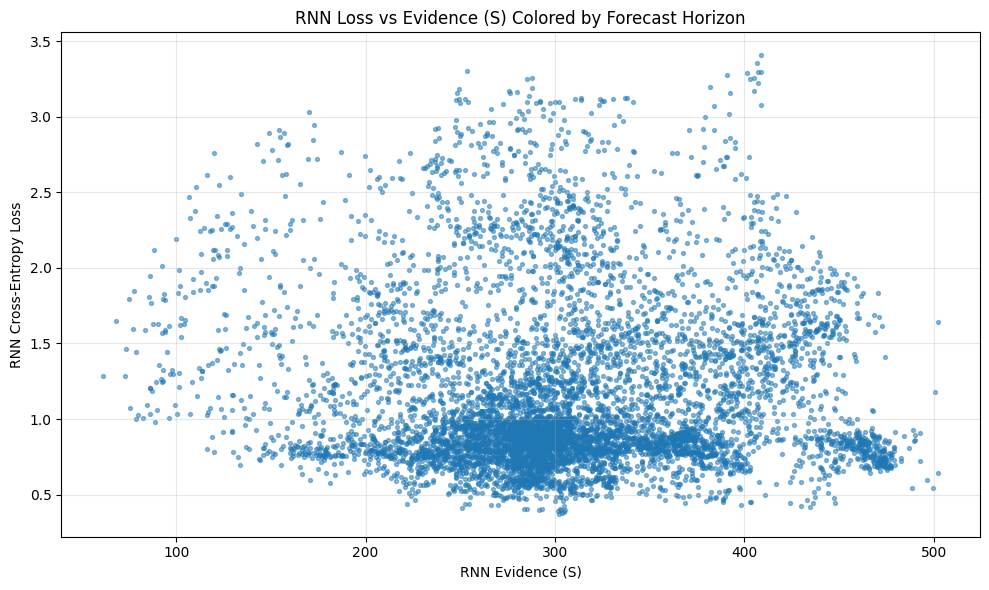

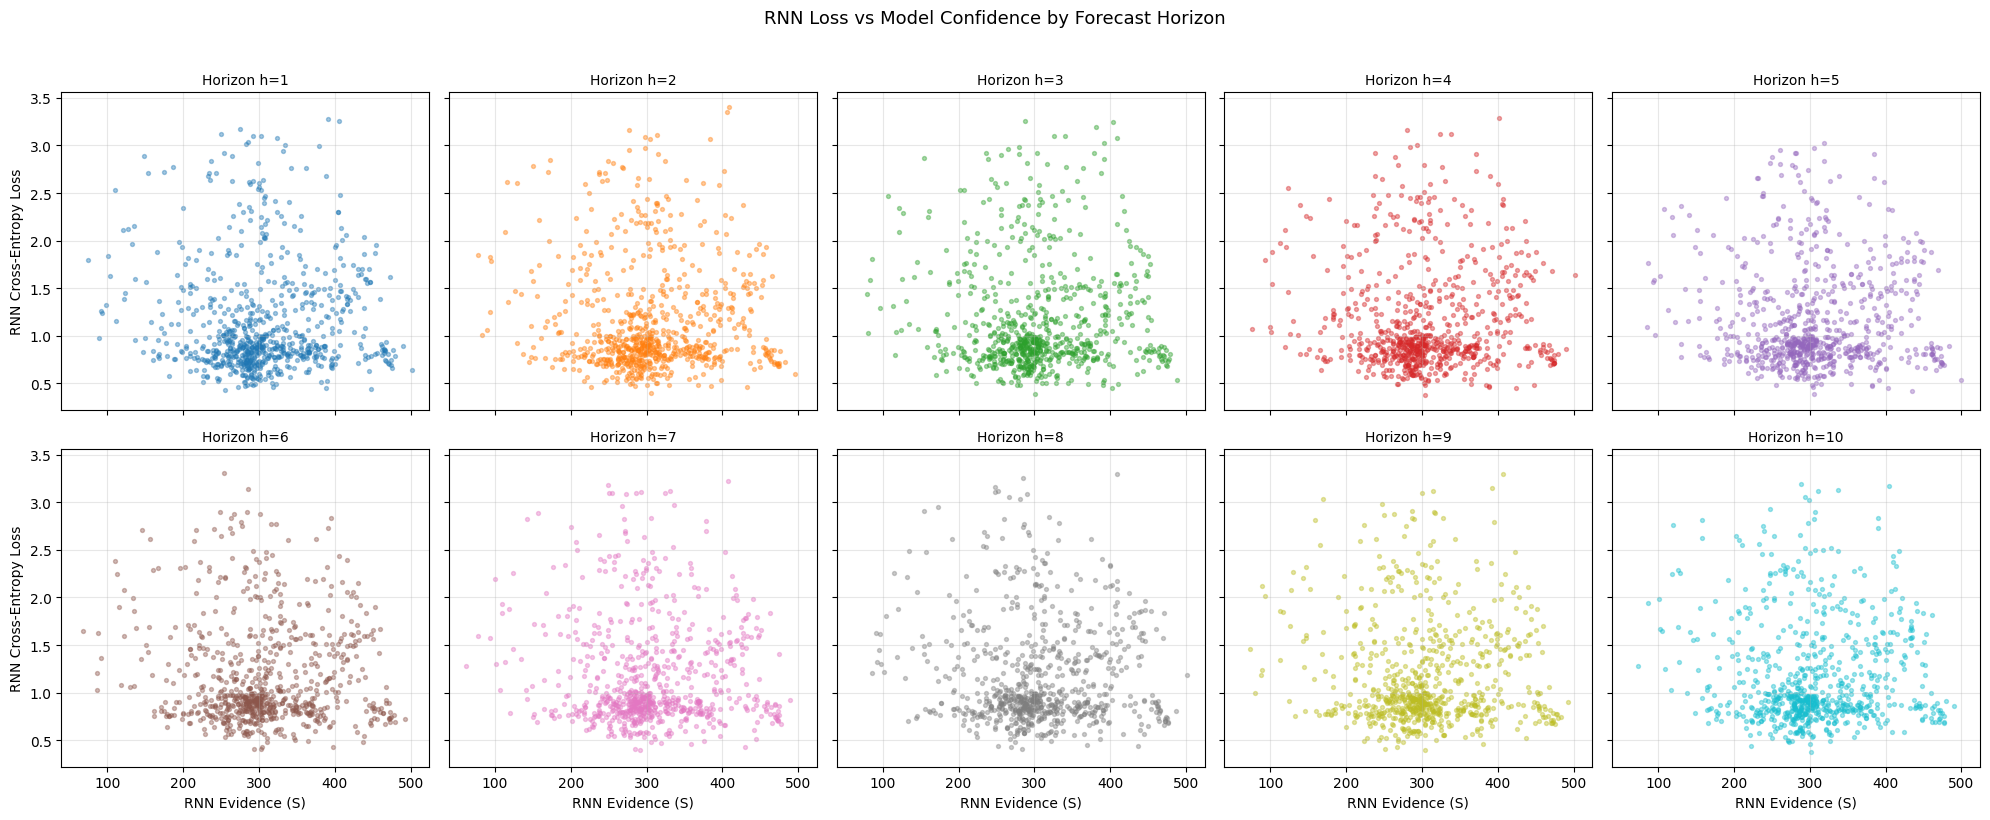

In [ ]:
# Scatter plot of RNN loss vs RNN evidence (S), colored by forecast horizon
# Flatten s and loss across all horizons, with horizon label
s_flat = rnn_s_test[:, :, 0].flatten()
loss_flat = rnn_loss_test.flatten()
fig = plt.figure(figsize=(10, 6))
scatter = plt.scatter(s_flat, loss_flat, alpha=0.5, s=8)
plt.xlabel('RNN Evidence (S)')
plt.ylabel('RNN Cross-Entropy Loss')
plt.title('RNN Loss vs Evidence (S) Colored by Forecast Horizon')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True, sharex=True)
axes = axes.flatten()

for h in range(forecast_horizon):
    ax = axes[h]
    s_h = rnn_s_test[:, h, 0]
    loss_h = rnn_loss_test[:, h]

    sc = ax.scatter(s_h, loss_h, alpha=0.4, s=8, c=f'C{h}')
    ax.set_title(f'Horizon h={h+1}', fontsize=10)
    ax.grid(True, alpha=0.3)
    if h % 5 == 0:
        ax.set_ylabel('RNN Cross-Entropy Loss')
    if h >= 5:
        ax.set_xlabel('RNN Evidence (S)')

fig.suptitle('RNN Loss vs Model Confidence by Forecast Horizon', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()